<a href="https://colab.research.google.com/github/Li2angel/BatteryInsight/blob/main/notebooks/02_aging_aware_soc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1: Aging-Aware SOC Estimation
**Research question:** Does including battery-aging information improve ML State-of-Charge (SOC) estimation?

**Dataset:** NASA Li-Ion Battery Aging Dataset (cell B0005).

**Target:** SOC, derived by Coulomb counting.

**Evaluation philosophy:** we don't just maximise R². For every model we ask
1. is it accurate?
2. does it generalise?
3. would a BMS trust it? So we report **train *and* test** metrics, time-aware cross-validation, and an explicit overfitting analysis.

## 1. Setup & data

In [1]:
!git clone --depth 1 https://github.com/XiuzeZhou/NASA.git nasa_repo 2>/dev/null
DATA_DIR = 'nasa_repo/dataset'

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, joblib
from scipy.io import loadmat
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

os.makedirs('figures',exist_ok=True); os.makedirs('models',exist_ok=True)

## 2. Loader: SOC via Coulomb counting

In [2]:
def load_battery(path, name):
    cycles = loadmat(path)[name][0,0]['cycle'][0]
    samples, dc = [], 0
    for c in cycles:
        if c['type'][0] != 'discharge': continue
        d=c['data'][0,0]; cap=float(d['Capacity'][0][0]); amb=float(c['ambient_temperature'][0][0])
        V,I,T,t=d['Voltage_measured'][0],d['Current_measured'][0],d['Temperature_measured'][0],d['Time'][0]
        dc+=1; dt=np.diff(t,prepend=t[0]); ah=np.cumsum(np.abs(I)*dt)/3600.0
        total=ah[-1] if ah[-1]>0 else cap; soc=1.0-ah/total
        for k in range(len(V)):
            samples.append((dc,V[k],I[k],T[k],t[k],soc[k],cap,amb))
    return pd.DataFrame(samples, columns=['cycle','voltage','current','temperature','time','soc','capacity','amb_temp'])

df = load_battery(f'{DATA_DIR}/B0005.mat','B0005')
print('samples:',df.shape,'| cycles:',df.cycle.nunique()); df.head(3)

samples: (50285, 8) | cycles: 168


,cycle,voltage,current,temperature,time,soc,capacity,amb_temp
0,1,4.191492,-0.004902,24.330034,0.000,1.000000,1.856487,24.0
1,1,4.190749,-0.001478,24.325993,16.781,0.999996,1.856487,24.0
2,1,3.974871,-2.012528,24.389085,35.703,0.994315,1.856487,24.0


## 3. Feature engineering
Instantaneous + temporal (within-cycle) + a lean, non-redundant aging set (`cycle`, `norm_cap`).

In [3]:
g=df.groupby('cycle')
df['roll_v']     = g['voltage'].transform(lambda s: s.rolling(5,min_periods=1).mean())
df['roll_v_std'] = g['voltage'].transform(lambda s: s.rolling(5,min_periods=1).std()).fillna(0)
df['dv']         = g['voltage'].transform(lambda s: s.diff()).fillna(0)
df['di']         = g['current'].transform(lambda s: s.diff()).fillna(0)
df['norm_cap']   = df['capacity']/df['capacity'].iloc[0]

base_feats  = ['voltage','current','temperature','roll_v','roll_v_std','dv','di']
aging_feats = base_feats + ['cycle','norm_cap']

## 4. Splits & metrics
**Chronological split** (train = earliest 80% of cycles, test = latest 20%): mimics a deployed BMS predicting future behaviour from past data. We never shuffle (that would leak future cycles into training).

**Metric choice:** we report RMSE, MAE and R². MAPE is deliberately excluded for SOC; SOC reaches exactly 0 at end-of-discharge, so a percentage error divides by zero and is undefined. (MAPE is appropriate for SOH in Module 2, where values stay ~0.5 - 1.0.)

In [4]:
cyc=np.sort(df.cycle.unique()); split=int(0.8*len(cyc))
tr=df[df.cycle.isin(cyc[:split])]; te=df[df.cycle.isin(cyc[split:])]
print(f'train cycles: {len(cyc[:split])} | test cycles (most aged): {len(cyc[split:])}')

def scores(y,p):
    return dict(RMSE=np.sqrt(mean_squared_error(y,p)), MAE=mean_absolute_error(y,p),
                R2=r2_score(y,p))

train cycles: 134 | test cycles (most aged): 34


## 5. Model comparison: TRAIN *and* TEST (with vs without aging features)
Reporting both sets is how we detect overfitting; reporting the ablation is how we answer the research question.

In [5]:
def make(name):
    if name=='LinearReg':   return LinearRegression()
    if name=='RandomForest':return RandomForestRegressor(n_estimators=80,max_depth=14,n_jobs=-1,random_state=0)
    return xgb.XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=-1,random_state=0)

In [6]:
rows=[]

for name in ['LinearReg','RandomForest','XGBoost']:
    for tag,feats in [('base',base_feats),('aging',aging_feats)]:
        m=make(name); m.fit(tr[feats],tr.soc)
        s_tr=scores(tr.soc,m.predict(tr[feats])); s_te=scores(te.soc,m.predict(te[feats]))
        rows.append({'Model':f'{name} ({tag})',
                     'tr_RMSE':s_tr['RMSE'],'te_RMSE':s_te['RMSE'],
                     'tr_MAE':s_tr['MAE'],'te_MAE':s_te['MAE'],
                     'tr_R2':s_tr['R2'],'te_R2':s_te['R2']})

pd.DataFrame(rows).set_index('Model').round(4)

,tr_RMSE,te_RMSE,tr_MAE,te_MAE,tr_R2,te_R2
Model,,,,,,
LinearReg (base),0.0692,0.0780,0.0563,0.0626,0.9503,0.9416
LinearReg (aging),0.0622,0.0775,0.0485,0.0521,0.9599,0.9424
RandomForest (base),0.0100,0.0438,0.0038,0.0263,0.9990,0.9816
RandomForest (aging),0.0014,0.0218,0.0009,0.0093,1.0000,0.9955
XGBoost (base),0.0126,0.0411,0.0064,0.0255,0.9983,0.9838
XGBoost (aging),0.0022,0.0216,0.0016,0.0082,0.9999,0.9955


## 6. Overfitting analysis (the part that matters)
The tree models hit train R² ≈ 1.0 with a slightly worse test score, *looks* like overfitting. We test that claim two ways:
1. **Regularize** the XGBoost model. If the gap is variance-overfitting, regularization should close it.
2. **Compare chronological vs random split.** If a random split removes the gap, the gap is **distribution shift** (aged-cell extrapolation), not memorization.

In [7]:
def gap(model, tr_, te_, feats=aging_feats):
    model.fit(tr_[feats],tr_.soc)
    return (np.sqrt(mean_squared_error(tr_.soc,model.predict(tr_[feats]))),
            np.sqrt(mean_squared_error(te_.soc,model.predict(te_[feats]))))

In [8]:
unreg=xgb.XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=-1,random_state=0)
reg  =xgb.XGBRegressor(n_estimators=150,max_depth=3,learning_rate=0.05,subsample=0.8,
                       colsample_bytree=0.8,reg_lambda=2.0,min_child_weight=5,n_jobs=-1,random_state=0)

for tag,m in [('unregularized',unreg),('regularized',reg)]:
    a,b=gap(m,tr,te); print(f'{tag:14s} train RMSE={a:.4f}  test RMSE={b:.4f}  gap={b-a:.4f}')

r_tr,r_te=train_test_split(df,test_size=0.2,random_state=0,shuffle=True)
a,b=gap(xgb.XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=-1,random_state=0),r_tr,r_te)
print(f'{"RANDOM split":14s} train RMSE={a:.4f}  test RMSE={b:.4f}  gap={b-a:.4f}  <- gap vanishes => distribution shift, not memorization')

unregularized  train RMSE=0.0022  test RMSE=0.0216  gap=0.0194
regularized    train RMSE=0.0126  test RMSE=0.0313  gap=0.0187
RANDOM split   train RMSE=0.0026  test RMSE=0.0031  gap=0.0006  <- gap vanishes => distribution shift, not memorization


## 7. Time-aware cross-validation
`TimeSeriesSplit` over cycles (expanding window) gives a consistency estimate, not a single lucky split.

In [9]:
tscv=TimeSeriesSplit(n_splits=5); fold=[]

for k,(tri,tei) in enumerate(tscv.split(cyc),1):
    a=df[df.cycle.isin(cyc[tri])]; b=df[df.cycle.isin(cyc[tei])]
    m=xgb.XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=-1,random_state=0)
    m.fit(a[aging_feats],a.soc); rr=np.sqrt(mean_squared_error(b.soc,m.predict(b[aging_feats])))
    fold.append(rr); print(f'fold {k}: {len(tri)} -> {len(tei)} cycles | RMSE={rr:.4f}')

print(f'CV RMSE = {np.mean(fold):.4f} +/- {np.std(fold):.4f}')

fold 1: 28 -> 28 cycles | RMSE=0.0241
fold 2: 56 -> 28 cycles | RMSE=0.0563
fold 3: 84 -> 28 cycles | RMSE=0.0548
fold 4: 112 -> 28 cycles | RMSE=0.0197
fold 5: 140 -> 28 cycles | RMSE=0.0170
CV RMSE = 0.0344 +/- 0.0174


## 8. Diagnostics & permutation importance

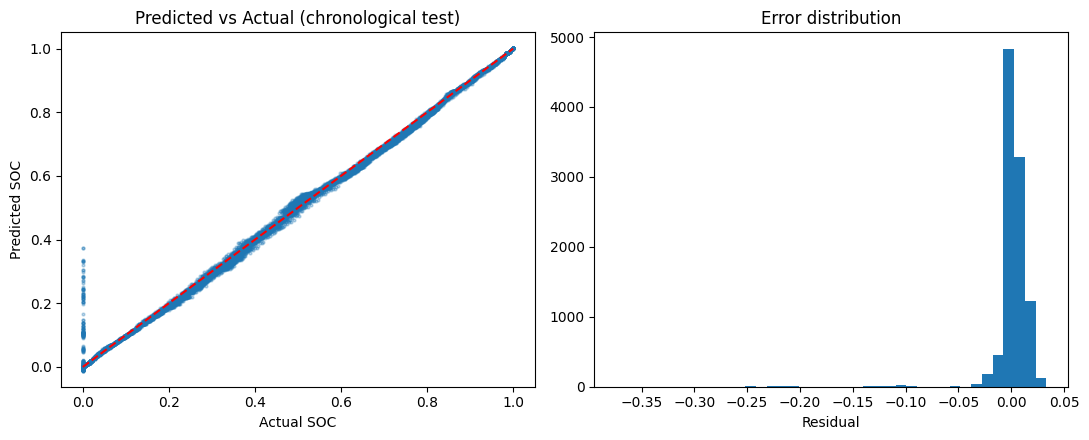

In [10]:
best=xgb.XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=-1,random_state=0)
best.fit(tr[aging_feats],tr.soc); pred=best.predict(te[aging_feats])

fig,ax=plt.subplots(1,2,figsize=(11,4.5))
ax[0].scatter(te.soc,pred,s=4,alpha=.3); ax[0].plot([0,1],[0,1],'r--')
ax[0].set_xlabel('Actual SOC'); ax[0].set_ylabel('Predicted SOC'); ax[0].set_title('Predicted vs Actual (chronological test)')
ax[1].hist(te.soc-pred,bins=40); ax[1].set_xlabel('Residual'); ax[1].set_title('Error distribution')
plt.tight_layout(); plt.savefig('figures/m1_diagnostics.png',dpi=120); plt.show()

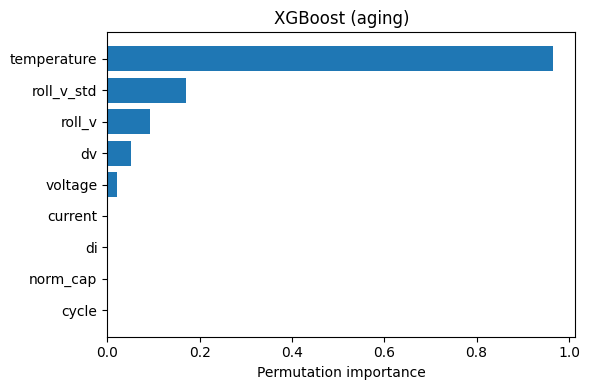

In [11]:
pi=permutation_importance(best,te[aging_feats],te.soc,n_repeats=5,random_state=0,n_jobs=-1)
order=np.argsort(pi.importances_mean)

plt.figure(figsize=(6,4)); plt.barh(np.array(aging_feats)[order],pi.importances_mean[order])
plt.xlabel('Permutation importance'); plt.title('XGBoost (aging)'); plt.tight_layout()
plt.savefig('figures/m1_perm_importance.png',dpi=120); plt.show()

## 9. Discussion (drop into README / report)
**Finding (research question).** Adding aging features (`cycle`, `norm_cap`) roughly **halves** SOC error for nonlinear models (XGBoost test RMSE ~0.041 -> ~0.022). Linear regression barely benefits, so the aging effect is nonlinear.

**Overfitting analysis.** Tree models reach train R² ~ 1.0 with worse test scores. But
1. regularization does **not** close the gap and
2. a random split removes it almost entirely (test R² 0.9955 -> 0.9999).

The gap is therefore **distribution shift**; extrapolating to the most-aged held-out cycles, not variance-overfitting. The near-perfect random-split score is exactly the misleading result that chronological splitting is designed to prevent.

**Cross-validation.** Time-aware CV RMSE ~ 0.034 +/- 0.017; early folds (little aging history) are hardest, later folds easiest, consistent with the distribution-shift reading.

**Metric choice.** MAPE is excluded for SOC because SOC reaches zero (undefined percentage error); RMSE/MAE/R² are the appropriate metrics here. MAPE is reserved for SOH in Module 2.

**Permutation importance.** Aging features show ~0 individual importance because `cycle` and `norm_cap` are collinear (permuting one leaves the info in the other); the **ablation**, not per-feature importance, is the reliable evidence.

**BMS implication.** An age-blind SOC model degrades on aged cells precisely when accurate SOC matters most; aging-aware estimation is worthwhile and must be evaluated chronologically.

## 10. Save artifacts

In [12]:
joblib.dump(best,'models/m1_soc_xgboost.joblib')
print('saved:',os.listdir('models'),os.listdir('figures'))

saved: ['m1_soc_xgboost.joblib'] ['m1_perm_importance.png', 'm1_diagnostics.png']
